In [ ]:
for file in `ls *.bam*`
do
samtools mpileup -l /data2/chenruipu/data/xulingna/snp/all_snp.bed -q 1 -t DP,AD -m 2 -F 0.002 -uvf /data2/chenruipu/refdata-gex-GRCh38-2024-A/fasta/genome.fa --output $file.vcf $file
done

In [ ]:
import vcfpy
import pandas as pd
import os
from pathlib import Path  
root = '/data2/chenruipu/data/xulingna/snp/bam/output/0.2_output'
folder_path=Path(root)
os.chdir(root)
for file in folder_path.glob('*.vcf'):
	print(str(file).split('-')[1].split('.merge.')[0].split('.')[0])
	reader = vcfpy.Reader.from_path(file)
	import pandas as pd
	all_snp=pd.read_csv('/data2/chenruipu/data/xulingna/snp/all_snp.bed',header=None,sep='\t')
	all_snp[['#chrom','pos','ref','alt']]=all_snp[3].str.split(':',expand=True)
	all_snp=all_snp[['#chrom','pos','ref','alt']]
	snp_info=pd.DataFrame(columns=['#CHROM','POS','REF','ALT','REF_COUNT','ALT_COUNT'])
	for record in reader:
		if len(record.calls[0].data['AD'])>=3:
				#if record.ALT
				print(record.CHROM)
				print(record.POS)
				print(record.calls[0].data['AD'][:-1])
				print(record.REF[0])
				print([alt.value for alt in record.ALT][:-1])
				new_row={'#CHROM':record.CHROM,'POS':record.POS,'REF':record.REF[0],'ALT':[alt.value for alt in record.ALT][0],'REF_COUNT':record.calls[0].data['AD'][0],'ALT_COUNT':record.calls[0].data['AD'][1]}
				snp_info=snp_info._append(new_row, ignore_index=True)

In [2]:
import vcfpy
import pandas as pd
import os
from pathlib import Path  
root = '/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/'
folder_path=Path(root)
os.chdir(root)
import pandas as pd
all_snp=pd.read_csv('/data2/chenruipu/data/xulingna/snp/all_snp.bed',header=None,sep='\t')
all_snp[['#chrom','pos','ref','alt']]=all_snp[3].str.split(':',expand=True)
all_snp=all_snp[['#chrom','pos','ref','alt']]
for file in folder_path.glob('*.vcf'):
	sample_name=str(file).split('/')[-1].split('list.merge.')[0].split('.bam')[0]
	reader = vcfpy.Reader.from_path(file)
	snp_info=pd.DataFrame(columns=['#chrom','pos',f'{sample_name}_ref',f'{sample_name}_alt'])
	print(str(file))
	for record in reader:
		if len(record.calls[0].data['AD'])>=3:
				# print(record.CHROM)
				# print(record.POS)
				# print(record.calls[0].data['AD'][:-1])
				# print(record.REF[0])
				# print([alt.value for alt in record.ALT][:-1])
				# print(record.CHROM,record.POS)
				new_row={'#chrom':record.CHROM,'pos':str(record.POS),f'{sample_name}_ref':record.calls[0].data['AD'][0],f'{sample_name}_alt':record.calls[0].data['AD'][1]}
				snp_info=snp_info._append(new_row, ignore_index=True)
	all_snp=pd.merge(all_snp,snp_info,on=['#chrom','pos'],how='left')
	# all_snp[f'{sample_name}_ref']=0
	# all_snp[f'{sample_name}_alt']=0
	all_snp=all_snp.drop_duplicates(subset=['#chrom','pos'])
	all_snp.to_csv('18month_snp_female.tsv', sep='\t',index=False)
		

/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.4-18month_female_output3.list.merge.sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.6-Input1_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.90-18month_female_output2.list.merge.sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.8-Input1_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.85-Input2_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.85-18month_female_output1.list.merge.sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.85-Input3_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.85-Input1_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.8-Input2_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.4-Input1_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/0.6-18month_female_output2.list.merge.sort.bam.vcf
/data2/chenruipu/data/xulingn

In [5]:
str(file).split('/')[-1].split('.merge.')[0].split('.')[0]

'18month_male_output2'

In [2]:
import vcfpy
import pandas as pd
import os
from pathlib import Path  
root = '/data2/chenruipu/data/xulingna/snp/bam/input/0.2_input/'
folder_path=Path(root)
os.chdir(root)
import pandas as pd
all_snp=pd.read_csv('/data2/chenruipu/data/xulingna/snp/all_snp.bed',header=None,sep='\t')
all_snp[['#chrom','pos','ref','alt']]=all_snp[3].str.split(':',expand=True)
all_snp=all_snp[['#chrom','pos','ref','alt']]
for file in folder_path.glob('*.vcf'):
	sample_name=str(file).split('-')[1].split('.merge.')[0].split('.')[0]
	reader = vcfpy.Reader.from_path(file)
	snp_info=pd.DataFrame(columns=['#chrom','pos',f'{sample_name}_ref',f'{sample_name}_alt'])
	for record in reader:
		if len(record.calls[0].data['AD'])>=3:
				# print(record.CHROM)
				# print(record.POS)
				# print(record.calls[0].data['AD'][:-1])
				# print(record.REF[0])
				# print([alt.value for alt in record.ALT][:-1])
				# print(record.CHROM,record.POS)
				new_row={'#chrom':record.CHROM,'pos':str(record.POS),f'{sample_name}_ref':record.calls[0].data['AD'][0],f'{sample_name}_alt':record.calls[0].data['AD'][1]}
				snp_info=snp_info._append(new_row, ignore_index=True)
	all_snp=pd.merge(all_snp,snp_info,on=['#chrom','pos'],how='left')

In [13]:
snp_info=snp_info[(snp_info['REF_COUNT']>0)&(not any(x == 0 for x in snp_info['ALT_COUNT']))&(not any(len(x)>1 for x in snp_info['ALT']))]
snp_info.to_csv('snp_info.tsv',sep='\t')

提取ref和alt的bam文件

In [1]:
import pysam 
mysam = '/data2/chenruipu/data/xulingna/snp/bam/input/Input1_sort.bam'
sam_rd = pysam.AlignmentFile(mysam, 'rb')  # bam文件，指定使用二进制读取
for rec in sam_rd:
    print(rec.reference_name)
    print(rec.reference_start)
    print(rec.reference_end)
    print(rec.reference_start<rec.reference_end)
    break
sam_rd.close()


chr1
103682
103832
True


In [1]:
import pandas as pd 
genelist=['CCDC92','FTO',
'FTSJ3',
'MTOR',
'MAP1LC3A',
'ACSS2',
'EDEM2',
'UQCC1',
'FIG4',
'ATF6B',
'NUDT3',
'SNRPC',
'IGFBP3']

In [2]:
snp_info=pd.read_csv('enhancer_gene_TF.tsv',sep='\t')
snp_info_selected=snp_info[snp_info['gene_name'].isin(genelist)]

In [3]:
snp_info_selected = snp_info_selected.dropna(subset=['geneSymbol'])



In [4]:
snp_info_selected = snp_info_selected[snp_info_selected['stage']=='M18']

In [ ]:
snp_info_selected.to_csv('enhancer_gene_TF_selected_11_11.tsv',sep='\t')

In [1]:
import pandas as pd
new = pd.read_csv('M18_female_new_methond_type.csv')
old = pd.read_csv('M18_female_old_methond_type.csv')

In [2]:
diff = pd.merge(new, old, on=['Row.names'], how='outer', indicator=True).query("_merge == 'left_only'")
#diff = pd.merge(new, old, on=['Row.names'], how='outer', indicator=True)
diff['LCF_abs'] = abs(diff['LFC_dif_x'])
diff = diff.sort_values(by = ['LCF_abs'],ascending=False,ignore_index=True)
high80 = diff[['Row.names','LCF_abs']].head(80)
midle40 = diff.loc[range(183,223)][['Row.names','LCF_abs']]
low40 = diff.loc[range(480,520)][['Row.names','LCF_abs']]

In [3]:
diff = pd.merge(new, old, on=['Row.names'], how='outer', indicator=True).query("_merge == 'both'")
#diff = pd.merge(new, old, on=['Row.names'], how='outer', indicator=True)
diff['LCF_abs'] = abs(diff['LFC_dif_x'])
diff = diff.sort_values(by = ['LCF_abs'],ascending=False,ignore_index=True)
both_high20 = diff[['Row.names','LCF_abs']].head(20)
both_midle10 = diff.loc[range(144,154)][['Row.names','LCF_abs']]
both_low10 = diff.loc[range(321,331)][['Row.names','LCF_abs']]

In [4]:
select200 = pd.concat([high80,both_high20,midle40,both_midle10,low40,both_low10])

In [ ]:
snp_bed = pd.DataFrame(columns=['chr','start','end','id'])
for id in list(set(select200['Row.names'])):
	id_bed = id.split(':')
	new_row = pd.DataFrame({'chr':[id_bed[0]],'start':[int(id_bed[1])-50],'end':[int(id_bed[1])+50],'id':id})
	snp_bed=pd.concat([snp_bed,new_row])
snp_bed.to_csv('M18_new_old_select200.bed',sep='\t',index=False,header=False)

In [ ]:
bedtools getfasta -name -fi /data5/chenruipu/data/wangchao/translatomer/Translatomer-main-crp/data/hg38/hg38.fa -bed M18_new_old_select200.bed -fo M18_new_old_select200_ref.fasta

In [6]:
from Bio import SeqIO
with open ('M18_new_old_select200_alt.fasta','w') as alt_fasta:
	for record in SeqIO.parse('M18_new_old_select200_ref.fasta','fasta'):
		alt_fasta.write(f'>{record.id}\n')
		alt = str(record.id).split(':')[3]
		new_seq=str(record.seq)[:49]+alt+str(record.seq)[50:]
		alt_fasta.write(f'{new_seq}\n')

In [ ]:
import pandas as pd 
M18_selected=pd.read_csv('M18_new_old_top30.tsv',sep='\t')

In [5]:
snp_bed = pd.DataFrame(columns=['chr','start','end','id'])
for id in list(set(M18_selected['Row.names'])):
	id_bed = id.split(':')
	new_row = pd.DataFrame({'chr':[id_bed[0]],'start':[int(id_bed[1])-175],'end':[int(id_bed[1])+175],'id':id})
	snp_bed=pd.concat([snp_bed,new_row])
	

In [6]:
snp_bed.to_csv('M18_new_old_top30.bed',sep='\t',index=False,header=False)

In [ ]:
bedtools getfasta -name -fi /data5/chenruipu/data/wangchao/translatomer/Translatomer-main-crp/data/hg38/hg38.fa -bed M18_new_old_top30.bed -fo M18_new_old_top30_ref.fasta
#seqkit subseq /data5/chenruipu/data/wangchao/translatomer/Translatomer-main-crp/data/hg38/hg38.fa --bed M18_new_old_top30.bed > M18_new_old_top30_ref.fasta

In [7]:
from Bio import SeqIO
with open ('M18_new_old_top30_alt.fasta','w') as alt_fasta:
	for record in SeqIO.parse('M18_new_old_top30_ref.fasta','fasta'):
		alt_fasta.write(f'>{record.id}\n')
		alt = str(record.id).split(':')[3]
		new_seq=str(record.seq)[:174]+alt+str(record.seq)[175:]
		alt_fasta.write(f'{new_seq}\n')



In [1]:
from Bio import SeqIO
import pandas as pd
ref_df = pd.DataFrame(columns=['seq_id','seq'])
alt_df = pd.DataFrame(columns=['seq_id','seq'])
for record in SeqIO.parse('snpM18_ref.fasta','fasta'):
	new_row = pd.DataFrame({'seq_id':[record.id],'seq':[record.seq]})
	ref_df=pd.concat([ref_df,new_row])
	alt = str(record.id).split(':')[3]
	new_seq=str(record.seq)[:39]+alt+str(record.seq)[40:]
	new_row = pd.DataFrame({'seq_id':[record.id],'seq':[new_seq]})
	alt_df=pd.concat([alt_df,new_row])

In [2]:
alt_df.to_csv('snpM18_alt.tsv',index=False,header=False,sep='\t')
ref_df.to_csv('snpM18_ref.tsv',index=False,header=False,sep='\t')

In [ ]:
import pandas as pd 
human_tpm=pd.read_csv('/data4/yanwei/02_Project/02_A031_Xu_AAV_STARR_human_capture/02_RNA/03_FeatureCount/all_feature_matrix_TPM_avg.txt',sep='\t',header=None)


In [1]:
import pysam 
import os 
snp_name = 'chr1:11201963:A:G'
snp_chr = snp_name.split(':')[0]
snp_position = int(snp_name.split(':')[1])
snp_ref =snp_name.split(':')[2]
snp_alt =snp_name.split(':')[3]

#root = os.chdir('/data2/chenruipu/data/xulingna/snp/bam/output')
input_bam = pysam.AlignmentFile('/data2/chenruipu/data/xulingna/snp/bam/output/3week_output.bam','rb')
output_ref_bam = pysam.AlignmentFile('/data2/chenruipu/data/xulingna/snp/bam/input/3week_output.ref.bam', 'wb', template=input_bam)
output_alt_bam = pysam.AlignmentFile('/data2/chenruipu/data/xulingna/snp/bam/input/3week_output.alt.bam', 'wb', template=input_bam)
count = 0
for read in input_bam:
	if (snp_chr == read.reference_name) and (snp_position>=read.reference_start + 1) and (snp_position<=read.reference_end + 1):
		start_dif = snp_position - (read.reference_start+1)
		if start_dif >= 150:
			continue
		if read.query_sequence[start_dif] == snp_ref:
			output_ref_bam.write(read)
			print(f'{snp_name} ref')
		elif read.query_sequence[start_dif] == snp_alt:
			output_alt_bam.write(read)
			print(f'{snp_name} alt')
		else:
			count = count+1
	else:
		output_ref_bam.write(read)
		output_alt_bam.write(read)
		# print( read.reference_name )
		# print(f'{read.reference_start + 1}')
		# print(f'{read.mapping_quality}')
		# print(f'{read.query_sequence}')
		# print(f'{read.reference_end+1}')
print(f'loss {count} seqs')
input_bam.close()
output_ref_bam.close()
output_alt_bam.close()

chr1:11201963:A:G alt
chr1:11201963:A:G alt
chr1:11201963:A:G alt
chr1:11201963:A:G alt
chr1:11201963:A:G alt
chr1:11201963:A:G alt
chr1:11201963:A:G alt
chr1:11201963:A:G alt
chr1:11201963:A:G alt
chr1:11201963:A:G alt
chr1:11201963:A:G alt
chr1:11201963:A:G alt
chr1:11201963:A:G alt
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201963:A:G ref
chr1:11201

In [10]:
start_dif

151

In [ ]:
print( read.reference_name )
print(f'{read.reference_start + 1}')
print(f'{read.mapping_quality}')
print(f'{read.query_sequence}')
print(f'{read.reference_end+1}')

In [15]:
root = os.chdir('/data2/chenruipu/data/xulingna/snp/bam/output')
bam_files = os.listdir(root)
bam_files = [f for f in bam_files if (f.endswith('sort.bam') and ('header' not in f) ) ]

In [ ]:
samtools index input.alt.bam
bamCoverage \
-b input.alt.bam \
-o input.alt.bigwig \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50

samtools index input.ref.bam
bamCoverage \
-b input.ref.bam \
-o input.ref.bigwig \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50

samtools index 3week_output.ref.bam
bamCoverage \
-b 3week_output.ref.bam \
-o 3week_output.ref.bigwig \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50

samtools index 3week_output.alt.bam
bamCoverage \
-b 3week_output.alt.bam \
-o 3week_output.alt.bigwig \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50

samtools index 11week_output.ref.bam
bamCoverage \
-b 11week_output.ref.bam \
-o 11week_output.ref.bigwig \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50

samtools index 11week_output.alt.bam
bamCoverage \
-b 11week_output.alt.bam \
-o 11week_output.alt.bigwig \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50

samtools index 18month_output.ref.bam
bamCoverage \
-b 18month_output.ref.bam \
-o 18month_output.ref.bigwig \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50

samtools index 18month_output.alt.bam
bamCoverage \
-b 18month_output.alt.bam \
-o 18month_output.alt.bigwig \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50

samtools index 18month_female_output1.list.merge.sort.ref.bam
bamCoverage \
-b 18month_female_output1.list.merge.sort.ref.bam \
-o 18month_female_output1.list.merge.sort.ref.bigwig \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50

samtools index 18month_female_output1.list.merge.sort.alt.bam
bamCoverage \
-b 18month_female_output1.list.merge.sort.alt.bam \
-o 18month_female_output1.list.merge.sort.alt.bigwig \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50



In [2]:
'''
this scripts can split bam by Allele genotype
snp format chr:position:ref:alt example (chr1:3289032:A:G)
bam file requires format of name as file_name.bam
'''
import argparse
import pysam 

parser = argparse.ArgumentParser(description='manual to this script')
parser.add_argument("--snp", type=str, default=False )
parser.add_argument("--bam", type=str, default=False )
args = parser.parse_args()
snp_name = args.snp
snp_chr = snp_name.split(':')[0]
snp_position = int(snp_name.split(':')[1])
snp_ref =snp_name.split(':')[2]
snp_alt =snp_name.split(':')[3]
bam_name = args.bam
#root = os.chdir('/data2/chenruipu/data/xulingna/snp/bam/output')
input_bam = pysam.AlignmentFile(bam_name,'rb')
ref_output_bam_name = bam_name.split('.bam')[0]+'.ref.bam'
alt_output_bam_name = bam_name.split('.bam')[0]+'.alt.bam'
output_ref_bam = pysam.AlignmentFile(ref_output_bam_name, 'wb', template=input_bam)
output_alt_bam = pysam.AlignmentFile(alt_output_bam_name, 'wb', template=input_bam)
for read in input_bam:
	if (snp_chr == read.reference_name) and (snp_position>=read.reference_start + 1) and (snp_position<=read.reference_end + 1):
		start_dif = snp_position - (read.reference_start+1)
		if start_dif >=len(read.query_sequence) :
			continue
		if read.query_sequence[start_dif-1] == snp_ref:
			output_ref_bam.write(read)
			print(f'{snp_name} ref')
		elif read.query_sequence[start_dif-1] == snp_alt:
			output_alt_bam.write(read)
			print(f'{snp_name} alt')
	else:
		output_ref_bam.write(read)
		output_alt_bam.write(read)
input_bam.close()
output_ref_bam.close()
output_alt_bam.close()

usage: ipykernel_launcher.py [-h] [--snp SNP] [--bam BAM]
ipykernel_launcher.py: error: unrecognized arguments: --f=/data2/chenruipu/.local/share/jupyter/runtime/kernel-v37861a016cba2cd94eeed3841c215bb9b7a111041.json


SystemExit: 2

In [ ]:
for i in range(0,100):
	print(i)

In [23]:
import pysam 
snp_name = 'chr2:23771561:G:A'
snp_chr = snp_name.split(':')[0]
snp_position = int(snp_name.split(':')[1])
snp_ref =snp_name.split(':')[2]
snp_alt =snp_name.split(':')[3]
input_bam = pysam.AlignmentFile('/data2/chenruipu/data/xulingna/snp/bam/input/Input3_sort.bam','rb')
count = 0 
for read in input_bam:
	if (snp_chr == read.reference_name) and (snp_position>=read.reference_start+1) and (snp_position<=read.reference_end+1):
		start_dif = snp_position - (read.reference_start+1)
		if start_dif>=len(read.query_sequence):
			continue
		print(start_dif)
		if read.query_sequence[start_dif] == snp_ref:
			#output_ref_bam.write(read)
			print(read.reference_start+1)
			print(read.reference_end + 1)
			print(f'{snp_name} ref')
			print(read.query_sequence)
		elif read.query_sequence[start_dif] == snp_alt:
			#output_alt_bam.write(read)
			print(read.reference_start+1)
			print(read.reference_end + 1)
			print(f'{snp_name} alt')
			print(read.query_sequence)
		else :
			count = count+1
			print(read.reference_start + 1)
			print(read.reference_end + 1)
			print(read.query_sequence)
	else:
		pass
print(count)

149
23771412
23771562
chr2:23771561:G:A ref
TATGATGAGAAATGTAGGCTTTTTGTAGACATCATTTATCACTGAACTGAAAAGCGGGGATAGGGGGAATAATTTTGTTCCAGTAAAAAAATTTGACTTACAAAAACAGGCTGTCAGCTTGATGATAGTCTGCTGACCCCTGGTTTAGAG
149
23771412
23771562
chr2:23771561:G:A ref
TATGATGAGAAATGTAGGCTTTTTGTAGACATCATTTATCACTGAACTGAAAAGCGGGGATAGGGGGAATAATTTTGTTCCAGTAAAAAAATTTGACTTACAAAAACAGGCTGTCAGCTTGATGATAGTCTGCTGACCCCTGGTTTAGAG
149
23771412
23771562
chr2:23771561:G:A ref
TATGATGAGAAATGTAGGCTTTTTGTAGACATCATTTATCACTGAACTGAAAAGCGGGGATAGGGGGAATAATTTTGTTCCAGTAAAAAAATTTGACTTACAAAAACAGGCTGTCAGCTTGATGATAGTCTGCTGACCCCTGGTTTAGAG
149
23771412
23771562
chr2:23771561:G:A ref
TATGATGAGAAATGTAGGCTTTTTGTAGACATCATTTATCACTGAACTGAAAAGCGGGGATAGGGGGAATAATTTTGTTCCAGTAAAAAAATTTGACTTACAAAAACAGGCTGTCAGCTTGATGATAGTCTGCTGACCCCTGGTTTAGAG
149
23771412
23771562
chr2:23771561:G:A ref
TATGATGAGAAATGTAGGCTTTTTGTAGACATCATTTATCACTGAACTGAAAAGCGGGGATAGGGGGAATAATTTTGTTCCAGTAAAAAAATTTGACTTACAAAAACAGGCTGTCAGCTTGATGATAGTCTGCTGACCCCTGGTTTAGAG
149
23771412
23771562
chr

In [21]:
read.query_sequence

'TAATTTTGTTCCAGTAAAAAAATTTGACTTACAAAAACAGGCTGTCAGCTTGATGATAGTCTGCTGACCCCTGGTTTAGA'

In [21]:
input_bam = pysam.AlignmentFile('/data2/chenruipu/data/xulingna/snp/bam/output/18month_female_output1.list.merge.sort.bam','rb')
for read in input_bam:
	print(read.query_name)
	print(read.reference_start)
	print(read.reference_end)
	break
input_bam.close()

A00917:1366:HGG7GDSX7:4:1157:13087:9784
777880
778030


In [ ]:
print(read.reference_start+1)
print(read.reference_end + 1)

11201813
11201963


In [27]:
read.query_sequence

'AAAAATTTTTTTGAGATGCAGTCTTGCTCTGCCATCTAGGCTGGAATGCAGGGGCACGACTGTGGCTCTCTGCAGCCTCTAAACTCCTGGACTCAAGTAATCCCCCCGCCTTAGCCTCCTGAGTAGCTAGGATTACAGCTTCATGCCACC'

In [1]:
import pandas as pd 
w3_enhancer = pd.read_csv('W3_enhancer.csv')
w11_enhancer = pd.read_csv('W11_enhancer.csv')
M18_enhancer = pd.read_csv('M18_enhancer.csv')
with pd.ExcelWriter('table_S2.xlsx') as writer:
	w3_enhancer.to_excel(writer, sheet_name='W3', index=False)
	w11_enhancer.to_excel(writer, sheet_name='W11', index=False)
	M18_enhancer.to_excel(writer, sheet_name='M18', index=False)


In [2]:
import pandas as pd 
w3_enhancer = pd.read_csv('W3_snp_respectively.csv')
w11_enhancer = pd.read_csv('W11_snp_respectively.csv')
M18_enhancer = pd.read_csv('M18_snp_respectively.csv')
with pd.ExcelWriter('table_S3.xlsx') as writer:
	w3_enhancer.to_excel(writer, sheet_name='W3', index=False)
	w11_enhancer.to_excel(writer, sheet_name='W11', index=False)
	M18_enhancer.to_excel(writer, sheet_name='M18', index=False)

count 标准化

In [ ]:
import pandas as pd 
import os
os.chdir('/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/11week/')
snp_count = pd.read_csv('11week_male.tsv',sep='\t')

In [2]:
snp_count.columns

Index(['#chrom', 'pos', 'ref', 'alt', 'M18-male-output-1-3_sort_ref',
       'M18-male-output-1-3_sort_alt', 'M18-male-output-1-1_sort_ref',
       'M18-male-output-1-1_sort_alt', 'M18-female-output-5_sort_ref',
       'M18-female-output-5_sort_alt', 'M18-male-output-1-6_sort_ref',
       'M18-male-output-1-6_sort_alt', 'M18-female-output-8_sort_ref',
       'M18-female-output-8_sort_alt', 'M18-female-output-7_sort_ref',
       'M18-female-output-7_sort_alt', 'M18-female-output-2_sort_ref',
       'M18-female-output-2_sort_alt', 'input_ref', 'input_alt',
       'M18-female-output-6_sort_ref', 'M18-female-output-6_sort_alt',
       'M18-male-output-1-2_sort_ref', 'M18-male-output-1-2_sort_alt',
       'M18-female-output-3_sort_ref', 'M18-female-output-3_sort_alt',
       'M18-male-output-1-4_sort_ref', 'M18-male-output-1-4_sort_alt',
       'M18-male-output-1-5_sort_ref', 'M18-male-output-1-5_sort_alt',
       'M18-female-output-4_sort_ref', 'M18-female-output-4_sort_alt',
       'M18-f

In [3]:
input_count = 18835826
month18_female_output1_count = 18367322
month18_female_output2_count = 19660766
month18_female_output3_count = 17261198
month18_female_output4_count = 15740218
month18_female_output5_count = 19048372
month18_female_output6_count = 19186602
month18_female_output7_count = 17912482
month18_female_output8_count = 17843650
month18_male_output1_count = 16607774
month18_male_output2_count = 18292382
month18_male_output3_count = 16619152
month18_male_output4_count = 15582972
month18_male_output5_count = 17315000
month18_male_output6_count = 19657484

#input count 标准化
snp_count['input_ref_scale'] = (snp_count['input_ref']/input_count)*1000000
snp_count['input_alt_scale'] = (snp_count['input_alt']/input_count)*1000000

#output count 标准化
snp_count['month18_female_output1_ref_scale'] = (snp_count['M18-female-output-1_sort_ref']/month18_female_output1_count)*1000000
snp_count['month18_female_output1_alt_scale'] = (snp_count['M18-female-output-1_sort_alt']/month18_female_output1_count)*1000000
snp_count['month18_female_output2_ref_scale'] = (snp_count['M18-female-output-2_sort_ref']/month18_female_output2_count)*1000000
snp_count['month18_female_output2_alt_scale'] = (snp_count['M18-female-output-2_sort_alt']/month18_female_output2_count)*1000000
snp_count['month18_female_output3_ref_scale'] = (snp_count['M18-female-output-3_sort_ref']/month18_female_output3_count)*1000000
snp_count['month18_female_output3_alt_scale'] = (snp_count['M18-female-output-3_sort_alt']/month18_female_output3_count)*1000000
snp_count['month18_female_output4_ref_scale'] = (snp_count['M18-female-output-4_sort_ref']/month18_female_output4_count)*1000000
snp_count['month18_female_output4_alt_scale'] = (snp_count['M18-female-output-4_sort_alt']/month18_female_output4_count)*1000000
snp_count['month18_female_output5_ref_scale'] = (snp_count['M18-female-output-5_sort_ref']/month18_female_output5_count)*1000000
snp_count['month18_female_output5_alt_scale'] = (snp_count['M18-female-output-5_sort_alt']/month18_female_output5_count)*1000000
snp_count['month18_female_output6_ref_scale'] = (snp_count['M18-female-output-6_sort_ref']/month18_female_output6_count)*1000000
snp_count['month18_female_output6_alt_scale'] = (snp_count['M18-female-output-6_sort_alt']/month18_female_output6_count)*1000000
snp_count['month18_female_output7_ref_scale'] = (snp_count['M18-female-output-7_sort_ref']/month18_female_output7_count)*1000000
snp_count['month18_female_output7_alt_scale'] = (snp_count['M18-female-output-7_sort_alt']/month18_female_output7_count)*1000000
snp_count['month18_female_output8_ref_scale'] = (snp_count['M18-female-output-8_sort_ref']/month18_female_output8_count)*1000000
snp_count['month18_female_output8_alt_scale'] = (snp_count['M18-female-output-8_sort_alt']/month18_female_output8_count)*1000000
snp_count['month18_male_output1_ref_scale'] = (snp_count['M18-male-output-1-1_sort_ref']/month18_male_output1_count)*1000000
snp_count['month18_male_output1_alt_scale'] = (snp_count['M18-male-output-1-1_sort_alt']/month18_male_output1_count)*1000000
snp_count['month18_male_output2_ref_scale'] = (snp_count['M18-male-output-1-2_sort_ref']/month18_male_output2_count)*1000000
snp_count['month18_male_output2_alt_scale'] = (snp_count['M18-male-output-1-2_sort_alt']/month18_male_output2_count)*1000000
snp_count['month18_male_output3_ref_scale'] = (snp_count['M18-male-output-1-3_sort_ref']/month18_male_output3_count)*1000000
snp_count['month18_male_output3_alt_scale'] = (snp_count['M18-male-output-1-3_sort_alt']/month18_male_output3_count)*1000000
snp_count['month18_male_output4_ref_scale'] = (snp_count['M18-male-output-1-4_sort_ref']/month18_male_output4_count)*1000000
snp_count['month18_male_output4_alt_scale'] = (snp_count['M18-male-output-1-4_sort_alt']/month18_male_output4_count)*1000000
snp_count['month18_male_output5_ref_scale'] = (snp_count['M18-male-output-1-5_sort_ref']/month18_male_output5_count)*1000000
snp_count['month18_male_output5_alt_scale'] = (snp_count['M18-male-output-1-5_sort_alt']/month18_male_output5_count)*1000000
snp_count['month18_male_output6_ref_scale'] = (snp_count['M18-male-output-1-6_sort_ref']/month18_male_output6_count)*1000000
snp_count['month18_male_output6_alt_scale'] = (snp_count['M18-male-output-1-6_sort_alt']/month18_male_output6_count)*1000000

统计位点深度

In [1]:
import vcfpy
import pandas as pd
import os
from pathlib import Path  
root = '/data2/chenruipu/data/xulingna/snp/bam/output/'
folder_path=Path(root)
os.chdir(root)
import pandas as pd
all_snp=pd.read_csv('/data2/chenruipu/data/xulingna/snp/all_snp.bed',header=None,sep='\t')
all_snp[['#chrom','pos','ref','alt']]=all_snp[3].str.split(':',expand=True)
all_snp=all_snp[['#chrom','pos','ref','alt']]
snp_coverage = {}
snp_variant_coverage = {}
for file in folder_path.glob('*.vcf'):
	sample_name=str(file).split('/')[-1].split('.merge.')[0].split('.')[0]
	reader = vcfpy.Reader.from_path(file)
	print(str(file))
	snp_coverage[sample_name]=[]
	snp_variant_coverage[sample_name]=[]
	for record in reader:
		if len(record.calls[0].data['AD'])>=3:
				snp_coverage[sample_name].append(record.calls[0].data['DP'])
				snp_variant_coverage[sample_name].append(record.calls[0].data['AD'][0])
				snp_variant_coverage[sample_name].append(record.calls[0].data['AD'][1])
	# all_snp.to_csv('snp_count.tsv', sep='\t',index=False)

/data2/chenruipu/data/xulingna/snp/bam/output/18month_male_output2.merge.sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/18month_female_output2.list.merge.sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/18month_male_output1.merge.sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/18month_female_output3.list.merge.sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/Input1_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/18month_female_output1.list.merge.sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/Input2_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/Input3_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/18month_male_output3.merge.sort.bam.vcf


In [2]:
import numpy as np
print('snp_coverage')
print('input mean')
print(np.mean(snp_coverage['Input1_sort']+snp_coverage['Input2_sort']+snp_coverage['Input3_sort']))
print('output mean')
print(np.mean(snp_coverage['18month_female_output1']+snp_coverage['18month_female_output2']+snp_coverage['18month_female_output3']))
print('input median')
print(np.median(snp_coverage['Input1_sort']+snp_coverage['Input2_sort']+snp_coverage['Input3_sort']))
print('output median')
print(np.median(snp_coverage['18month_female_output1']+snp_coverage['18month_female_output2']+snp_coverage['18month_female_output3']))

#np.median(snp_variant_coverage['11week_male_output1']+snp_variant_coverage['11week_male_output2']+snp_variant_coverage['11week_male_output3']+snp_variant_coverage['Input1_sort']+snp_variant_coverage['Input2_sort']+snp_variant_coverage['Input3_sort'])

snp_coverage
input mean
2287.530186279644
output mean
3377.7276323075707
input median
1917.0
output median
3053.0


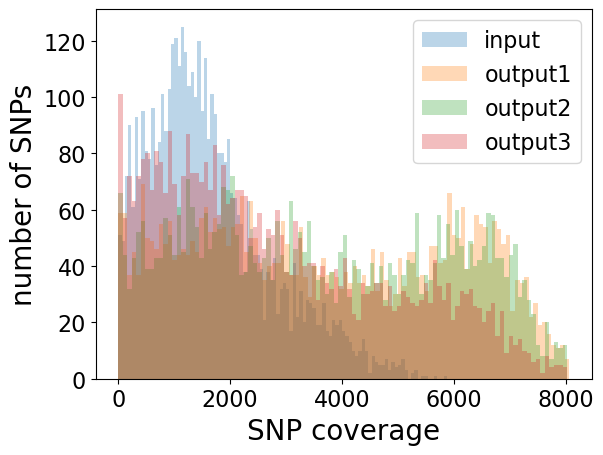

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42   # TrueType（关键）
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['svg.fonttype'] = 'none'  # SVG 也可编辑

plt.rcParams.update({
    'font.size': 18,          # 全局默认字体
    'axes.labelsize': 20,     # 坐标轴标题
    'axes.titlesize': 20,
    'xtick.labelsize': 16,    # x 轴刻度
    'ytick.labelsize': 16,    # y 轴刻度
    'legend.fontsize': 16    # 图例
})

plt.hist(x=snp_coverage['Input1_sort'], bins=100,label='input',alpha=0.3)
#plt.hist(x=snp_coverage['Input2_sort'], bins=100,label='input2',alpha=0.3)
#plt.hist(x=snp_coverage['Input3_sort'], bins=100,label='input3',alpha=0.3)
plt.hist(x=snp_coverage['18month_female_output1'], bins=100,label='output1',alpha=0.3)
plt.hist(x=snp_coverage['18month_female_output2'], bins=100,label='output2',alpha=0.3)
plt.hist(x=snp_coverage['18month_female_output3'], bins=100,label='output3',alpha=0.3)
# plt.hist(x=snp_coverage['18month_male_output1'], bins=100,label='male1',alpha=0.3)
# plt.hist(x=snp_coverage['18month_male_output2'], bins=100,label='male2',alpha=0.3)
# plt.hist(x=snp_coverage['18month_male_output3'], bins=100,label='male3',alpha=0.3)
plt.xlabel('SNP coverage')
plt.ylabel('number of SNPs')
plt.legend(loc="upper right")
plt.savefig('/data2/chenruipu/data/xulingna/snp/SNP_coverage.pdf',dpi = 300,bbox_inches='tight')
plt.show()

In [3]:
import numpy as np
print('snp_coverage')
print('input mean')
print(np.mean(snp_coverage['Input1_sort']+snp_coverage['Input2_sort']+snp_coverage['Input3_sort']))
print('output mean')
print(np.mean(snp_coverage['18month_female_output1']+snp_coverage['18month_female_output2']+snp_coverage['18month_female_output3']))
print('input median')
print(np.median(snp_coverage['Input1_sort']+snp_coverage['Input2_sort']+snp_coverage['Input3_sort']))
print('output median')
print(np.median(snp_coverage['18month_female_output1']+snp_coverage['18month_female_output2']+snp_coverage['18month_female_output3']))

#np.median(snp_variant_coverage['11week_male_output1']+snp_variant_coverage['11week_male_output2']+snp_variant_coverage['11week_male_output3']+snp_variant_coverage['Input1_sort']+snp_variant_coverage['Input2_sort']+snp_variant_coverage['Input3_sort'])

snp_coverage
input mean
2287.530186279644
output mean
3377.7276323075707
input median
1917.0
output median
3053.0


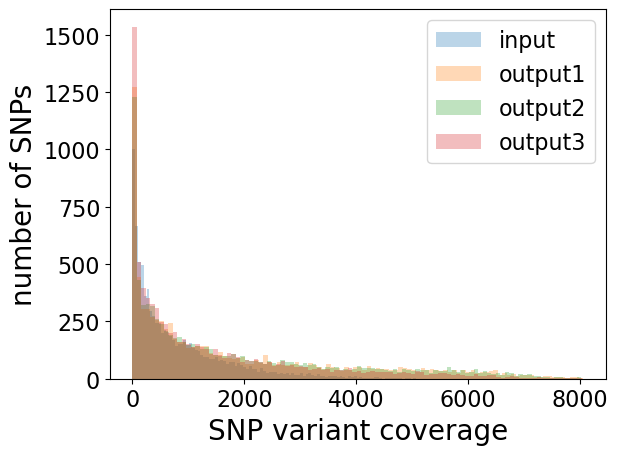

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42   # TrueType（关键）
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['svg.fonttype'] = 'none'  # SVG 也可编辑


plt.hist(x=snp_variant_coverage['Input1_sort'], bins=100,label='input',alpha=0.3)
#plt.hist(x=snp_variant_coverage['Input2_sort'], bins=100,label='input2',alpha=0.3)
#plt.hist(x=snp_variant_coverage['Input3_sort'], bins=100,label='input3',alpha=0.3)
plt.hist(x=snp_variant_coverage['18month_female_output1'], bins=100,label='output1',alpha=0.3)
plt.hist(x=snp_variant_coverage['18month_female_output2'], bins=100,label='output2',alpha=0.3)
plt.hist(x=snp_variant_coverage['18month_female_output3'], bins=100,label='output3',alpha=0.3)
# plt.hist(x=snp_variant_coverage['18month_male_output1'], bins=100,label='male1',alpha=0.3)
# plt.hist(x=snp_variant_coverage['18month_male_output2'], bins=100,label='male2',alpha=0.3)
# plt.hist(x=snp_variant_coverage['18month_male_output3'], bins=100,label='male3',alpha=0.3)
plt.xlabel('SNP variant coverage')
plt.ylabel('number of SNPs')
plt.legend(loc="upper right")
plt.savefig('/data2/chenruipu/data/xulingna/snp/SNP_variant_coverage.pdf',dpi = 300,bbox_inches='tight')
plt.show()

In [12]:
import numpy as np
print('snp_variant_coverage')
print('input mean')
print(np.mean(snp_variant_coverage['Input1_sort']+snp_variant_coverage['Input2_sort']+snp_variant_coverage['Input3_sort']))
print('output mean')
print(np.mean(snp_variant_coverage['18month_female_output1']+snp_variant_coverage['18month_female_output2']+snp_variant_coverage['18month_female_output3']))
print('input median')
print(np.median(snp_variant_coverage['Input1_sort']+snp_variant_coverage['Input2_sort']+snp_variant_coverage['Input3_sort']))
print('output median')
print(np.median(snp_variant_coverage['18month_female_output1']+snp_variant_coverage['18month_female_output2']+snp_variant_coverage['18month_female_output3']))

#np.median(snp_variant_coverage['11week_male_output1']+snp_variant_coverage['11week_male_output2']+snp_variant_coverage['11week_male_output3']+snp_variant_coverage['Input1_sort']+snp_variant_coverage['Input2_sort']+snp_variant_coverage['Input3_sort'])

snp_variant_coverage
input mean
1143.2922869753872
output mean
1688.3809034095405
input median
673.0
output median
947.0


In [1]:
import pandas as pd 
import os
os.chdir('/data2/chenruipu/data/xulingna/snp/bam/output/all_bam/')
snp_count = pd.read_csv('18month_snp_female.tsv',sep='\t')

In [2]:
month18_female_output1_count_02 = 5528759
month18_female_output2_count_02 = 5397041
month18_female_output3_count_02 = 3576242
month18_female_output1_count_04 = 11059895
month18_female_output2_count_04 = 10795343
month18_female_output3_count_04 = 7151923
month18_female_output1_count_06 = 16588338
month18_female_output2_count_06 = 16193553
month18_female_output3_count_06 = 10725863
month18_female_output1_count_08 = 22117044
month18_female_output2_count_08 = 21588169
month18_female_output3_count_08 = 14304161
month18_female_output1_count_085 = 23499417
month18_female_output2_count_085 = 22938460
month18_female_output3_count_085 = 15197072
month18_female_output1_count_09 = 24881075
month18_female_output2_count_09 = 24287721
month18_female_output3_count_09 = 16091321
month18_female_output1_count_095 = 26261379
month18_female_output2_count_095 = 25638089
month18_female_output3_count_095 = 16984184
input1_count_02=1885295
input2_count_02=3127926
input3_count_02=3261187
input1_count_04=3767744
input2_count_04=6254240
input3_count_04=6523140
input1_count_06=5650035
input2_count_06=9382095
input3_count_06=9780878
input1_count_08=7533027
input2_count_08=12508005
input3_count_08=13039848
input1_count_085=8004025
input2_count_085=13288957
input3_count_085=13854448
input1_count_09=8475420
input2_count_09=14070821
input3_count_09=14668512
input1_count_095=8947155
input2_count_095=14852225
input3_count_095=15483934


In [4]:
snp_count['Input1_02_ref_scale'] = (snp_count['0.2-Input1_sort_ref']/input1_count_02)*1000000
snp_count['Input1_02_alt_scale'] = (snp_count['0.2-Input1_sort_alt']/input1_count_02)*1000000
snp_count['Input2_02_ref_scale'] = (snp_count['0.2-Input2_sort_ref']/input2_count_02)*1000000
snp_count['Input2_02_alt_scale'] = (snp_count['0.2-Input2_sort_alt']/input2_count_02)*1000000
snp_count['Input3_02_ref_scale'] = (snp_count['0.2-Input3_sort_ref']/input3_count_02)*1000000
snp_count['Input3_02_alt_scale'] = (snp_count['0.2-Input3_sort_alt']/input3_count_02)*1000000
snp_count['Input1_04_ref_scale'] = (snp_count['0.4-Input1_sort_ref']/input1_count_04)*1000000
snp_count['Input1_04_alt_scale'] = (snp_count['0.4-Input1_sort_alt']/input1_count_04)*1000000
snp_count['Input2_04_ref_scale'] = (snp_count['0.4-Input2_sort_ref']/input2_count_04)*1000000
snp_count['Input2_04_alt_scale'] = (snp_count['0.4-Input2_sort_alt']/input2_count_04)*1000000
snp_count['Input3_04_ref_scale'] = (snp_count['0.4-Input3_sort_ref']/input3_count_04)*1000000
snp_count['Input3_04_alt_scale'] = (snp_count['0.4-Input3_sort_alt']/input3_count_04)*1000000
snp_count['Input1_06_ref_scale'] = (snp_count['0.6-Input1_sort_ref']/input1_count_06)*1000000
snp_count['Input1_06_alt_scale'] = (snp_count['0.6-Input1_sort_alt']/input1_count_06)*1000000
snp_count['Input2_06_ref_scale'] = (snp_count['0.6-Input2_sort_ref']/input2_count_06)*1000000
snp_count['Input2_06_alt_scale'] = (snp_count['0.6-Input2_sort_alt']/input2_count_06)*1000000
snp_count['Input3_06_ref_scale'] = (snp_count['0.6-Input3_sort_ref']/input3_count_06)*1000000
snp_count['Input3_06_alt_scale'] = (snp_count['0.6-Input3_sort_alt']/input3_count_06)*1000000
snp_count['Input1_08_ref_scale'] = (snp_count['0.8-Input1_sort_ref']/input1_count_08)*1000000
snp_count['Input1_08_alt_scale'] = (snp_count['0.8-Input1_sort_alt']/input1_count_08)*1000000
snp_count['Input2_08_ref_scale'] = (snp_count['0.8-Input2_sort_ref']/input2_count_08)*1000000
snp_count['Input2_08_alt_scale'] = (snp_count['0.8-Input2_sort_alt']/input2_count_08)*1000000
snp_count['Input3_08_ref_scale'] = (snp_count['0.8-Input3_sort_ref']/input3_count_08)*1000000
snp_count['Input3_08_alt_scale'] = (snp_count['0.8-Input3_sort_alt']/input3_count_08)*1000000
snp_count['Input1_085_ref_scale'] = (snp_count['0.85-Input1_sort_ref']/input1_count_085)*1000000
snp_count['Input1_085_alt_scale'] = (snp_count['0.85-Input1_sort_alt']/input1_count_085)*1000000
snp_count['Input2_085_ref_scale'] = (snp_count['0.85-Input2_sort_ref']/input2_count_085)*1000000
snp_count['Input2_085_alt_scale'] = (snp_count['0.85-Input2_sort_alt']/input2_count_085)*1000000
snp_count['Input3_085_ref_scale'] = (snp_count['0.85-Input3_sort_ref']/input3_count_085)*1000000
snp_count['Input3_085_alt_scale'] = (snp_count['0.85-Input3_sort_alt']/input3_count_085)*1000000
snp_count['Input1_09_ref_scale'] = (snp_count['0.90-Input1_sort_ref']/input1_count_09)*1000000
snp_count['Input1_09_alt_scale'] = (snp_count['0.90-Input1_sort_alt']/input1_count_09)*1000000
snp_count['Input2_09_ref_scale'] = (snp_count['0.90-Input2_sort_ref']/input2_count_09)*1000000
snp_count['Input2_09_alt_scale'] = (snp_count['0.90-Input2_sort_alt']/input2_count_09)*1000000
snp_count['Input3_09_ref_scale'] = (snp_count['0.90-Input3_sort_ref']/input3_count_09)*1000000
snp_count['Input3_09_alt_scale'] = (snp_count['0.90-Input3_sort_alt']/input3_count_09)*1000000
snp_count['Input1_095_ref_scale'] = (snp_count['0.95-Input1_sort_ref']/input1_count_095)*1000000
snp_count['Input1_095_alt_scale'] = (snp_count['0.95-Input1_sort_alt']/input1_count_095)*1000000
snp_count['Input2_095_ref_scale'] = (snp_count['0.95-Input2_sort_ref']/input2_count_095)*1000000
snp_count['Input2_095_alt_scale'] = (snp_count['0.95-Input2_sort_alt']/input2_count_095)*1000000
snp_count['Input3_095_ref_scale'] = (snp_count['0.95-Input3_sort_ref']/input3_count_095)*1000000
snp_count['Input3_095_alt_scale'] = (snp_count['0.95-Input3_sort_alt']/input3_count_095)*1000000
snp_count['month18_female_output1_ref_scale_02'] = (snp_count['0.2-18month_female_output1._ref']/month18_female_output1_count_02)*1000000
snp_count['month18_female_output1_alt_scale_02'] = (snp_count['0.2-18month_female_output1._alt']/month18_female_output1_count_02)*1000000
snp_count['month18_female_output2_ref_scale_02'] = (snp_count['0.2-18month_female_output2._ref']/month18_female_output2_count_02)*1000000
snp_count['month18_female_output2_alt_scale_02'] = (snp_count['0.2-18month_female_output2._alt']/month18_female_output2_count_02)*1000000
snp_count['month18_female_output3_ref_scale_02'] = (snp_count['0.2-18month_female_output3._ref']/month18_female_output3_count_02)*1000000
snp_count['month18_female_output3_alt_scale_02'] = (snp_count['0.2-18month_female_output3._alt']/month18_female_output3_count_02)*1000000
snp_count['month18_female_output1_ref_scale_04'] = (snp_count['0.4-18month_female_output1._ref']/month18_female_output1_count_04)*1000000
snp_count['month18_female_output1_alt_scale_04'] = (snp_count['0.4-18month_female_output1._alt']/month18_female_output1_count_04)*1000000
snp_count['month18_female_output2_ref_scale_04'] = (snp_count['0.4-18month_female_output2._ref']/month18_female_output2_count_04)*1000000
snp_count['month18_female_output2_alt_scale_04'] = (snp_count['0.4-18month_female_output2._alt']/month18_female_output2_count_04)*1000000
snp_count['month18_female_output3_ref_scale_04'] = (snp_count['0.4-18month_female_output3._ref']/month18_female_output3_count_04)*1000000
snp_count['month18_female_output3_alt_scale_04'] = (snp_count['0.4-18month_female_output3._alt']/month18_female_output3_count_04)*1000000
snp_count['month18_female_output1_ref_scale_06'] = (snp_count['0.6-18month_female_output1._ref']/month18_female_output1_count_06)*1000000
snp_count['month18_female_output1_alt_scale_06'] = (snp_count['0.6-18month_female_output1._alt']/month18_female_output1_count_06)*1000000
snp_count['month18_female_output2_ref_scale_06'] = (snp_count['0.6-18month_female_output2._ref']/month18_female_output2_count_06)*1000000
snp_count['month18_female_output2_alt_scale_06'] = (snp_count['0.6-18month_female_output2._alt']/month18_female_output2_count_06)*1000000
snp_count['month18_female_output3_ref_scale_06'] = (snp_count['0.6-18month_female_output3._ref']/month18_female_output3_count_06)*1000000
snp_count['month18_female_output3_alt_scale_06'] = (snp_count['0.6-18month_female_output3._alt']/month18_female_output3_count_06)*1000000
snp_count['month18_female_output1_ref_scale_08'] = (snp_count['0.8-18month_female_output1._ref']/month18_female_output1_count_08)*1000000
snp_count['month18_female_output1_alt_scale_08'] = (snp_count['0.8-18month_female_output1._alt']/month18_female_output1_count_08)*1000000
snp_count['month18_female_output2_ref_scale_08'] = (snp_count['0.8-18month_female_output2._ref']/month18_female_output2_count_08)*1000000
snp_count['month18_female_output2_alt_scale_08'] = (snp_count['0.8-18month_female_output2._alt']/month18_female_output2_count_08)*1000000
snp_count['month18_female_output3_ref_scale_08'] = (snp_count['0.8-18month_female_output3._ref']/month18_female_output3_count_08)*1000000
snp_count['month18_female_output3_alt_scale_08'] = (snp_count['0.8-18month_female_output3._alt']/month18_female_output3_count_08)*1000000
snp_count['month18_female_output1_ref_scale_085'] = (snp_count['0.85-18month_female_output1._ref']/month18_female_output1_count_085)*1000000
snp_count['month18_female_output1_alt_scale_085'] = (snp_count['0.85-18month_female_output1._alt']/month18_female_output1_count_085)*1000000
snp_count['month18_female_output2_ref_scale_085'] = (snp_count['0.85-18month_female_output2._ref']/month18_female_output2_count_085)*1000000
snp_count['month18_female_output2_alt_scale_085'] = (snp_count['0.85-18month_female_output2._alt']/month18_female_output2_count_085)*1000000
snp_count['month18_female_output3_ref_scale_085'] = (snp_count['0.85-18month_female_output3._ref']/month18_female_output3_count_085)*1000000
snp_count['month18_female_output3_alt_scale_085'] = (snp_count['0.85-18month_female_output3._alt']/month18_female_output3_count_085)*1000000
snp_count['month18_female_output1_ref_scale_09'] = (snp_count['0.90-18month_female_output1._ref']/month18_female_output1_count_09)*1000000
snp_count['month18_female_output1_alt_scale_09'] = (snp_count['0.90-18month_female_output1._alt']/month18_female_output1_count_09)*1000000
snp_count['month18_female_output2_ref_scale_09'] = (snp_count['0.90-18month_female_output2._ref']/month18_female_output2_count_09)*1000000
snp_count['month18_female_output2_alt_scale_09'] = (snp_count['0.90-18month_female_output2._alt']/month18_female_output2_count_09)*1000000
snp_count['month18_female_output3_ref_scale_09'] = (snp_count['0.90-18month_female_output3._ref']/month18_female_output3_count_09)*1000000
snp_count['month18_female_output3_alt_scale_09'] = (snp_count['0.90-18month_female_output3._alt']/month18_female_output3_count_09)*1000000
snp_count['month18_female_output1_ref_scale_095'] = (snp_count['0.95-18month_female_output1._ref']/month18_female_output1_count_095)*1000000
snp_count['month18_female_output1_alt_scale_095'] = (snp_count['0.95-18month_female_output1._alt']/month18_female_output1_count_095)*1000000
snp_count['month18_female_output2_ref_scale_095'] = (snp_count['0.95-18month_female_output2._ref']/month18_female_output2_count_095)*1000000
snp_count['month18_female_output2_alt_scale_095'] = (snp_count['0.95-18month_female_output2._alt']/month18_female_output2_count_095)*1000000
snp_count['month18_female_output3_ref_scale_095'] = (snp_count['0.95-18month_female_output3._ref']/month18_female_output3_count_095)*1000000
snp_count['month18_female_output3_alt_scale_095'] = (snp_count['0.95-18month_female_output3._alt']/month18_female_output3_count_095)*1000000

In [5]:
snp_count.to_csv('M18_snp_female_downsample.tsv', sep='\t',index=False)

In [1]:
import vcfpy
import pandas as pd
import os
from pathlib import Path  
root = '/data2/chenruipu/data/xulingna/snp/bam/output/11week/'
folder_path=Path(root)
os.chdir(root)
import pandas as pd
all_snp=pd.read_csv('/data2/chenruipu/data/xulingna/snp/all_snp.bed',header=None,sep='\t')
all_snp[['#chrom','pos','ref','alt']]=all_snp[3].str.split(':',expand=True)
all_snp=all_snp[['#chrom','pos','ref','alt']]
snp_coverage = {}
snp_variant_coverage = {}
for file in folder_path.glob('*.vcf'):
	sample_name=str(file).split('/')[-1].split('.merge.')[0].split('.')[0]
	reader = vcfpy.Reader.from_path(file)
	print(str(file))
	snp_coverage[sample_name]=[]
	snp_variant_coverage[sample_name]=[]
	for record in reader:
		if len(record.calls[0].data['AD'])>=3:
				snp_coverage[sample_name].append(record.calls[0].data['DP'])
				snp_variant_coverage[sample_name].append(record.calls[0].data['AD'][0])
				snp_variant_coverage[sample_name].append(record.calls[0].data['AD'][1])

/data2/chenruipu/data/xulingna/snp/bam/output/11week/11week_male_output1.merge.sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/11week/Input1_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/11week/Input2_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/11week/Input3_sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/11week/11week_male_output2.merge.sort.bam.vcf
/data2/chenruipu/data/xulingna/snp/bam/output/11week/11week_male_output3.merge.sort.bam.vcf


In [17]:
import numpy as np
np.mean(snp_coverage['11week_male_output1']+snp_coverage['11week_male_output2']+snp_coverage['11week_male_output3']+snp_coverage['Input1_sort']+snp_coverage['Input2_sort']+snp_coverage['Input3_sort'])
#np.median(snp_coverage['11week_male_output1']+snp_coverage['11week_male_output2']+snp_coverage['11week_male_output3']+snp_coverage['Input1_sort']+snp_coverage['Input2_sort']+snp_coverage['Input3_sort'])

2626.4601046560483

In [19]:
import numpy as np
np.mean(snp_variant_coverage['11week_male_output1']+snp_variant_coverage['11week_male_output2']+snp_variant_coverage['11week_male_output3']+snp_variant_coverage['Input1_sort']+snp_variant_coverage['Input2_sort']+snp_variant_coverage['Input3_sort'])
#np.median(snp_variant_coverage['11week_male_output1']+snp_variant_coverage['11week_male_output2']+snp_variant_coverage['11week_male_output3']+snp_variant_coverage['Input1_sort']+snp_variant_coverage['Input2_sort']+snp_variant_coverage['Input3_sort'])

1312.7267675031512

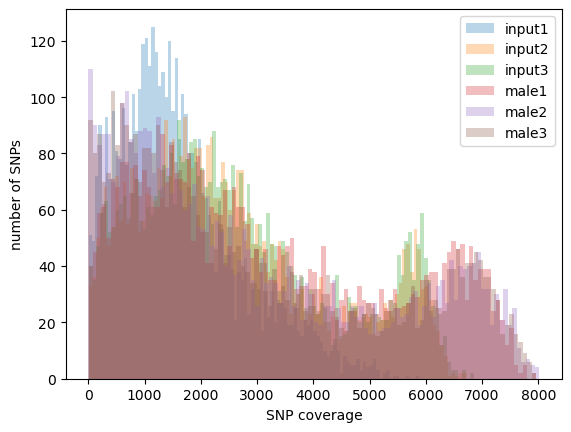

In [16]:
import matplotlib.pyplot as plt
import numpy as np

#plt.hist(x=snp_coverage['Input1_sort'], bins=100,label='input1',alpha=0.3)
#plt.hist(x=snp_coverage['Input2_sort'], bins=100,label='input2',alpha=0.3)
plt.hist(x=snp_coverage['Input3_sort'], bins=100,label='input3',alpha=0.3)
plt.hist(x=snp_coverage['11week_male_output1'], bins=100,label='male1',alpha=0.3)
plt.hist(x=snp_coverage['11week_male_output2'], bins=100,label='male2',alpha=0.3)
plt.hist(x=snp_coverage['11week_male_output3'], bins=100,label='male3',alpha=0.3)
plt.xlabel('SNP coverage')
plt.ylabel('number of SNPs')
plt.legend(loc="upper right")
plt.show()

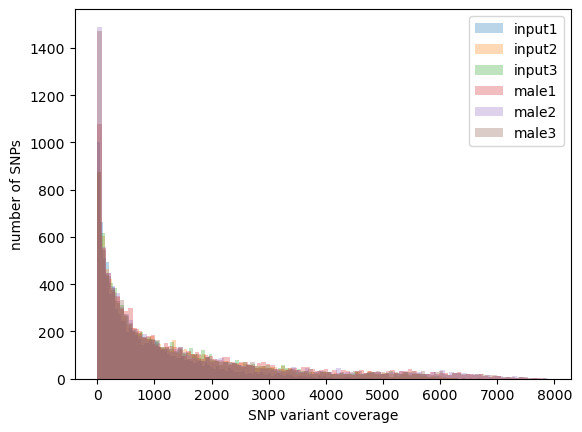

In [18]:
import matplotlib.pyplot as plt
import numpy as np

plt.hist(x=snp_variant_coverage['Input1_sort'], bins=100,label='input1',alpha=0.3)
plt.hist(x=snp_variant_coverage['Input2_sort'], bins=100,label='input2',alpha=0.3)
plt.hist(x=snp_variant_coverage['Input3_sort'], bins=100,label='input3',alpha=0.3)
plt.hist(x=snp_variant_coverage['11week_male_output1'], bins=100,label='male1',alpha=0.3)
plt.hist(x=snp_variant_coverage['11week_male_output2'], bins=100,label='male2',alpha=0.3)
plt.hist(x=snp_variant_coverage['11week_male_output3'], bins=100,label='male3',alpha=0.3)
plt.xlabel('SNP variant coverage')
plt.ylabel('number of SNPs')
plt.legend(loc="upper right")
plt.show()

In [1]:
import pandas as pd
W11_old=pd.read_csv('W11_male_old_methond_type.csv')
W11_new=pd.read_csv('W11_male_new_methond_type.csv')

In [4]:
difference_set=set(W11_new['Row.names'])-set(W11_old['Row.names'])
insert_set=set(set(W11_new['Row.names'])&set(W11_old['Row.names']))

In [6]:
difference_set=W11_new[W11_new['Row.names'].isin(list(difference_set))]

In [5]:
insert_set=W11_new[W11_new['Row.names'].isin(list(insert_set))]

In [ ]:
samtools index Input3_sort.alt.bam
bamCoverage \
-b Input3_sort.alt.bam \
-o Input3_sort.alt.bigwig \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50

In [ ]:
samtools index Input3_sort.ref.bam
bamCoverage \
-b Input3_sort.ref.bam \
-o Input3_sort.ref.bigwig \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50

In [ ]:
samtools index Input3_sort.bam
bamCoverage \
-b Input3_sort.bam \
-o Input3_sort.bigwig \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50

In [ ]:
samtools index 11week_male_output3.merge.sort.ref.bam
bamCoverage \
-b 11week_male_output3.merge.sort.ref.bam \
-o 11week_male_output3.merge.sort.ref.bw \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50

In [ ]:
samtools index 11week_male_output3.merge.sort.alt.bam
bamCoverage \
-b 11week_male_output3.merge.sort.alt.bam \
-o 11week_male_output3.merge.sort.alt.bw \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50

In [ ]:
samtools index 11week_male_output3.merge.sort.bam
bamCoverage \
-b 11week_male_output3.merge.sort.bam \
-o 11week_male_output3.merge.sort.bw \
--binSize 10 --normalizeUsing RPKM \
--scaleFactor 1 --numberOfProcessors 50

In [2]:
import pandas as pd 
all_snp =pd.read_csv('M18_all_snp_typ.csv')

In [3]:
all_snp_dup=all_snp[all_snp.duplicated(subset=['Row.names'],keep=False)]

In [4]:
reversed_snp = []
for snp in list(set(all_snp_dup['Row.names'])):
	count = len(set(all_snp_dup[all_snp_dup['Row.names']==snp]['Sig']))
	if count ==2 :
		reversed_snp.append(snp)

In [7]:
all_snp_dup[all_snp_dup['Row.names'].isin(reversed_snp)].to_csv('reversed_effective_snp.csv',index=False)

In [1]:
scRNA_snp = []
 
# 打开文件并逐行读取内容
with open('snpM18_scRNA.txt', 'r') as file:
    for line in file:
        scRNA_snp.append(line.strip())  # 去除每行末尾的换行符
 
print(scRNA_snp)

['chr6:34311624:T:G', 'chr6:32255481:T:C', 'chr20:34704973:C:T', 'chr16:53794154:C:T', 'chr1:11247196:G:C', 'chr6:32252707:C:G', 'chr16:53764710:G:T', 'chr20:34624251:G:A', 'chr12:123985786:T:C', 'chr6:34392019:G:A', 'chr16:53772233:T:C', 'chr20:35381727:C:T', 'chr1:11213965:G:A', 'chr20:35361116:A:G', 'chr1:11201963:A:G', 'chr12:123995826:G:C', 'chr20:35471850:G:A', 'chr6:109738751:G:A', 'chr1:11228701:G:A', 'chr1:11241657:A:G', 'chr20:34807137:C:T', 'chr20:34990448:A:G', 'chr7:45928488:G:C', 'chr20:35460841:C:T', 'chr20:34513297:C:G', 'chr12:123957333:C:G', 'chr20:34513848:G:C', 'chr1:11234417:T:A', 'chr20:35274101:C:T', 'chr1:11234885:T:A', 'chr16:53777876:A:G', 'chr16:53772368:C:G', 'chr12:124000096:C:G', 'chr16:53779455:T:G', 'chr20:34424725:A:G', 'chr12:123976156:C:A', 'chr20:35372647:T:C', 'chr20:35359927:T:C', 'chr20:34452168:G:A', 'chr20:35002781:T:C', 'chr20:34544560:C:T', 'chr20:35016604:T:C', 'chr6:34311623:G:A', 'chr6:32051969:G:C', 'chr20:34861966:T:C', 'chr20:34498817:A:

In [5]:
set(scRNA_snp)&set(reversed_snp)

{'chr20:35388671:G:C', 'chr20:35471850:G:A', 'chr6:109738751:G:A'}

In [7]:
import pandas as pd 
M18_eQTL = pd.read_csv('M18_effective_snp_eQTL_TF.tsv',sep='\t')
M18_eQTL = M18_eQTL.drop_duplicates(keep = 'last')
M18_eQTL['geneSymbol'] = M18_eQTL.apply(lambda row: row['providerName'] if pd.isna(row['geneSymbol']) else row['geneSymbol'], axis=1)
M18_eQTL.to_csv('M18_effective_snp_eQTL_TF.tsv',sep='\t',index=False)

In [13]:
import pandas as pd 
M18_eQTL = pd.read_csv('M18_effective_snp_eQTL_TF.tsv',sep='\t')

In [2]:
M18_eQTL_male = M18_eQTL[M18_eQTL['sex']=='male']
M18_eQTL_female = M18_eQTL[M18_eQTL['sex']=='female']

In [17]:
M18_eQTL_female = M18_eQTL_female[M18_eQTL_female['average_TF_tpm']>=20]
print(len(set(M18_eQTL_female['snp_id'])))
print(len(set(M18_eQTL_female[M18_eQTL_female['effect']=='strong']['snp_id'])))

272
239


In [4]:
print(len(set(M18_eQTL_male['snp_id'])))
print(len(set(M18_eQTL_male[M18_eQTL_male['effect']=='strong']['snp_id'])))

588
514


In [8]:
import pandas as pd 
all_snp = pd.read_csv('all_snp.rds.tsv',sep='\t')
negative_snp = pd.read_csv('/data2/chenruipu/data/xulingna/snp/loop_result/all_negtive_snp.txt')
all_negative_snp = all_snp[all_snp['SNP_id'].isin(negative_snp['snp_id'])]
print(len(set(all_negative_snp['SNP_id'])))
print(len(set(all_negative_snp[all_negative_snp['effect']=='strong']['SNP_id'])))

235
228


In [10]:
all_snp = pd.read_csv('all_snp.rds.tsv',sep='\t')
tpm=pd.read_csv('/data2/chenruipu/data/xulingna/snp/gene_tpm_muscle_skeletal.gct',sep='\t')
tpm['average_TF_tpm'] = tpm[list(tpm.columns)[3:]].mean(axis=1)
tpm=tpm[['Description','average_TF_tpm']]
tpm.columns=['geneSymbol','average_TF_tpm']

In [11]:
all_snp = pd.merge(all_snp,tpm,how='left')

In [18]:
all_snp= all_snp[all_snp['average_TF_tpm']>=20]
print(len(set(all_snp['SNP_id'])))
print(len(set(all_snp[all_snp['effect']=='strong']['SNP_id'])))

2252
1957


In [1]:
import pandas as pd 
import numpy as np
snp = pd.read_csv('M18_effective_snp_eQTL_TF_atac.tsv',sep=',')
hek293t_exp = pd.read_csv('hek293t/hek293t_RNAs_seq.cout',sep='\t')
selecet = ['chr20:35471850:G:A','chr20:35509307:G:A','chr4:119525893:A:G','chr1:11228561:G:A','chr20:34941963:T:G','chr20:35473753:C:T','chr20:35487861:T:G','chr2:27616672:T:C','chr20:34819901:A:C']

In [2]:
hek293t_exp['TPM1'] = hek293t_exp['SRR16495650.sort.filtered.rmdup.bam']/hek293t_exp['Length']*1000000/sum(hek293t_exp['SRR16495650.sort.filtered.rmdup.bam']/hek293t_exp['Length'])
hek293t_exp['TPM2'] = hek293t_exp['SRR16495651.sort.filtered.rmdup.bam']/hek293t_exp['Length']*1000000/sum(hek293t_exp['SRR16495651.sort.filtered.rmdup.bam']/hek293t_exp['Length'])
hek293t_exp['TPM3'] = hek293t_exp['SRR16495652.sort.filtered.rmdup.bam']/hek293t_exp['Length']*1000000/sum(hek293t_exp['SRR16495652.sort.filtered.rmdup.bam']/hek293t_exp['Length'])
hek293t_exp['TPM_avg'] = (hek293t_exp['TPM1']+hek293t_exp['TPM2']+hek293t_exp['TPM3'])/3
hek293t_exp_avg = hek293t_exp[['Geneid','TPM1','TPM2','TPM3','TPM_avg']]
hek293t_exp_avg.columns = ['geneSymbol','TPM1','TPM2','TPM3','hek293t_average']
snp = pd.merge(snp,hek293t_exp_avg,how='left',on = 'geneSymbol')
snp = snp[snp['snp_id'].isin(selecet)]

In [12]:
heatmap_matrix = snp[['geneSymbol','average_TF_tpm','hek293t_average']]
heatmap_matrix.columns = ['TF','GTEx_average_TPM','hek293t_average_TPM']
heatmap_matrix = heatmap_matrix.dropna (axis=0)
heatmap_matrix = heatmap_matrix.drop_duplicates(keep='first')
heatmap_matrix.index = heatmap_matrix['TF']
heatmap_matrix = heatmap_matrix[['GTEx_average_TPM','hek293t_average_TPM']]
heatmap_matrix = heatmap_matrix[(heatmap_matrix['GTEx_average_TPM']>5)]
#heatmap_matrix = heatmap_matrix.sort_values(by='GTEx_average_TPM')

In [1]:
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
 

#绘制热度图：
plt.figure(figsize=(20, 2))
plot=sns.heatmap(heatmap_matrix.T,cmap="YlGnBu",vmin=10,vmax=50)



plt.show()

NameError: name 'heatmap_matrix' is not defined

<Figure size 2000x200 with 0 Axes>

In [2]:
a = 1123

In [3]:
print('asda')

asda


新旧方法overlap

In [36]:
import pandas as pd 
old = pd.read_csv('M18_female_old_methond_type.csv')
new=pd.read_csv('M18_female_new_methond_type.csv')


In [42]:
#old = old[(old['log2FoldChange.y']>0.585)|(old['log2FoldChange.x']>0.585)]
new = new[((new['log2FoldChange.y']>0.585)&(new['padj.y']<0.05))|((new['log2FoldChange.x']>0.585)&(new['padj.x']<0.05))]

In [46]:
new = new[new['Row.names'].isin(snp_ingwas_list)]

In [49]:
new['Sig'].value_counts()

Sig
Up      412
Down    261
Name: count, dtype: int64

In [43]:
new

,Unnamed: 0,X,Row.names,baseMean.x,log2FoldChange.x,lfcSE.x,stat.x,pvalue.x,padj.x,baseMean.y,log2FoldChange.y,lfcSE.y,stat.y,pvalue.y,padj.y,fisher_result,LFC_dif,padj,Sig
2,32,32,chr1:11065809:G:A,172.195455,-1.224594,1.151859,-1.063145,2.877160e-01,5.169010e-01,1715.308909,2.202579,0.163579,13.464958,2.514596e-41,2.379366e-39,5.479756e-293,3.427173,1.331004e-291,Up
3,33,33,chr1:11066342:C:T,160.236002,1.262664,1.220952,1.034164,3.010596e-01,5.326115e-01,3516.313948,4.126183,0.194128,21.255007,2.963164e-100,1.147014e-97,1.414806e-180,2.863519,1.746978e-179,Up
4,34,34,chr1:11066375:C:G,183.327985,0.633386,1.232101,0.514070,6.072033e-01,8.051364e-01,3693.674724,3.297587,0.200798,16.422369,1.322996e-60,2.086414e-58,1.253086e-210,2.664201,1.873034e-209,Up
5,35,35,chr1:11066433:A:G,281.668453,-0.215293,0.834072,-0.258123,7.963122e-01,9.121556e-01,3705.744232,2.082741,0.155028,13.434601,3.791059e-41,3.509202e-39,5.918199e-236,2.298034,1.035545e-234,Up
6,36,36,chr1:11066460:C:T,438.973123,0.152139,0.723644,0.210241,8.334799e-01,9.277697e-01,3628.190847,1.480659,0.226794,6.528665,6.635842e-11,9.114650e-10,3.424898e-86,1.328520,1.837896e-85,Up
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,4428,4428,chr9:125273170:C:A,1931.678082,1.482679,0.146702,10.106726,5.157923e-24,2.580761e-22,314.064591,0.666908,0.184386,3.616923,2.981262e-04,1.502274e-03,4.182324e-41,-0.815771,1.226461e-40,Down
1046,4431,4431,chr9:125281525:T:G,1782.963855,3.160392,0.307520,10.277017,8.945321e-25,4.752063e-23,138.862994,-0.462634,0.148164,-3.122433,1.793631e-03,7.578242e-03,0.000000e+00,-3.623025,0.000000e+00,Down
1047,4433,4433,chr9:125293178:A:G,2211.768207,2.438004,0.214535,11.364129,6.309029e-30,5.429550e-28,680.496039,-0.621453,0.558983,-1.111757,2.662424e-01,4.648054e-01,0.000000e+00,-3.059458,0.000000e+00,Down
1048,4437,4437,chr9:125306109:G:A,4222.484031,1.403503,0.191753,7.319332,2.492087e-13,5.058231e-12,211.301667,-2.415352,0.714046,-3.382626,7.179625e-04,3.331031e-03,0.000000e+00,-3.818855,0.000000e+00,Down


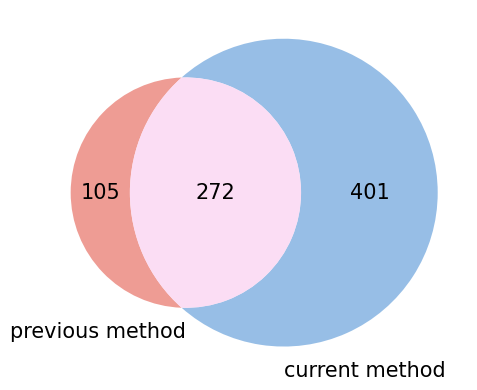

In [44]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# 三个示例列表
A = old['Row.names'].to_list()
B = new['Row.names'].to_list()


# 绘制二集合韦恩图
plt.figure(figsize=(5, 5))
venn = venn2(
    [set(A)&set(snp_ingwas_list), set(B)&set(snp_ingwas_list)],
    set_labels=('previous method', 'current method'),
    set_colors=('#EA8379', '#7DAEE0'),
    alpha=0.8
)

# 美化样式
for text in venn.set_labels:
    text.set_fontsize(15)
for text in venn.subset_labels:
    if text:  # 避免空区域报错
        text.set_fontsize(15)

plt.title("", fontsize=11)
plt.tight_layout()

# ✅ 保存为 PDF 文件
plt.savefig("old_new_method_overlap.pdf", format="pdf", bbox_inches="tight")

plt.show()


In [39]:
snp_ingwas_list

['chr1:11012060:C:T',
 'chr1:11012828:C:T',
 'chr1:11014193:A:G',
 'chr1:11014363:G:A',
 'chr1:11015454:T:C',
 'chr1:11018168:T:C',
 'chr1:11018255:G:C',
 'chr1:11018340:C:T',
 'chr1:11019020:A:G',
 'chr1:11019356:T:A',
 'chr1:11021823:G:T',
 'chr1:11026275:A:G',
 'chr1:11026382:C:T',
 'chr1:11026660:A:G',
 'chr1:11027467:G:A',
 'chr1:11027778:T:C',
 'chr1:11030859:C:A',
 'chr1:11031148:G:A',
 'chr1:11034982:C:T',
 'chr1:11040841:A:G',
 'chr1:11045049:C:T',
 'chr1:11046302:T:C',
 'chr1:11052779:T:C',
 'chr1:11059078:G:A',
 'chr1:11064828:T:C',
 'chr1:11064855:C:T',
 'chr1:11064886:G:A',
 'chr1:11064922:A:G',
 'chr1:11064993:T:C',
 'chr1:11065676:G:C',
 'chr1:11065809:G:A',
 'chr1:11066342:C:T',
 'chr1:11066375:C:G',
 'chr1:11066433:A:G',
 'chr1:11066460:C:T',
 'chr1:11066512:C:A',
 'chr1:11066884:C:T',
 'chr1:11067454:A:C',
 'chr1:11067707:C:A',
 'chr1:11067814:A:G',
 'chr1:11067944:A:G',
 'chr1:11068272:A:G',
 'chr1:11068597:G:A',
 'chr1:11069202:T:G',
 'chr1:11069377:T:C',
 'chr1:110

In [32]:
len(set(B)&set(snp_ingwas_list))

704

In [2]:
import pandas as pd 
scRNA_snp = pd.read_csv('/data2/chenruipu/data/xulingna/snp/scRNA/scripts/M18_cell_type_inner_change_snp.csv')

/tmp/ipykernel_51594/2285967204.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="group", y="value", data=df, inner=None, palette="pastel")


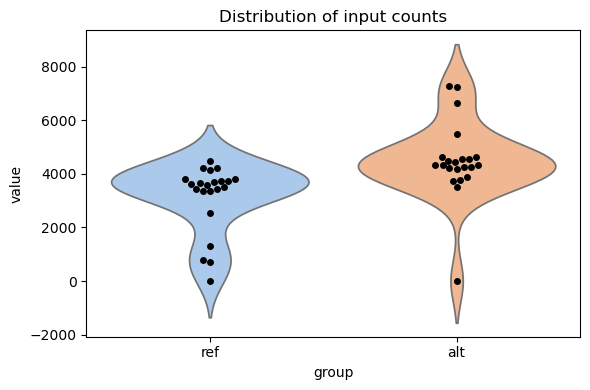

In [11]:
input_counts = list(set(scRNA_snp['input_alt_counts']))+list(set(scRNA_snp['input_ref_counts']))
import matplotlib.pyplot as plt
import numpy as np


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 示例数据
df = pd.DataFrame({
    "value": input_counts,
    "group": ["ref"]*22 + ["alt"]*22  # 如果有分组
})

plt.figure(figsize=(6,4))
sns.violinplot(x="group", y="value", data=df, inner=None, palette="pastel")
sns.swarmplot(x="group", y="value", data=df, color="k", size=5)
plt.title("Distribution of input counts")
plt.tight_layout()
plt.savefig("small_sample_violin.pdf")
plt.show()



In [17]:
import numpy as np
np.mean(input_counts)

3814.5227272727275

In [18]:
import numpy as np
np.mean(cell_counts)

578.9130434782609

In [13]:
cell_counts = scRNA_snp.groupby('snp_id')['cell_ref_counts'].sum().reset_index()['cell_ref_counts'].tolist()+scRNA_snp.groupby('snp_id')['cell_alt_counts'].sum().reset_index()['cell_alt_counts'].tolist()

/tmp/ipykernel_51594/1902013466.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="group", y="value", data=df, inner=None, palette="pastel")


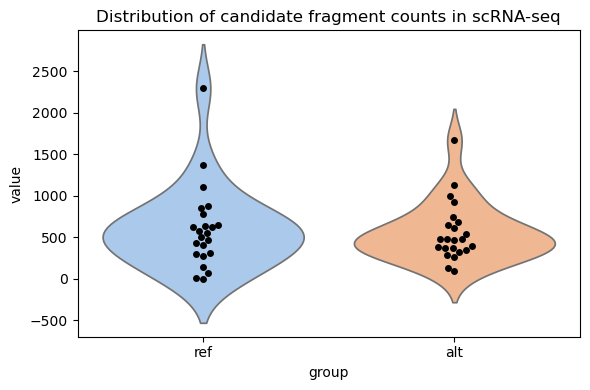

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 示例数据
df = pd.DataFrame({
    "value": cell_counts,
    "group": ["ref"]*23 + ["alt"]*23  # 如果有分组
})

plt.figure(figsize=(6,4))
sns.violinplot(x="group", y="value", data=df, inner=None, palette="pastel")
sns.swarmplot(x="group", y="value", data=df, color="k", size=5)
plt.title("Distribution of candidate fragment counts in scRNA-seq")
plt.tight_layout()
plt.savefig("output_sample_violin.pdf")
plt.show()

Monocyte mean:10.630434782608695


/tmp/ipykernel_51594/272113710.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="group", y="value", data=df, inner=None, palette="pastel")


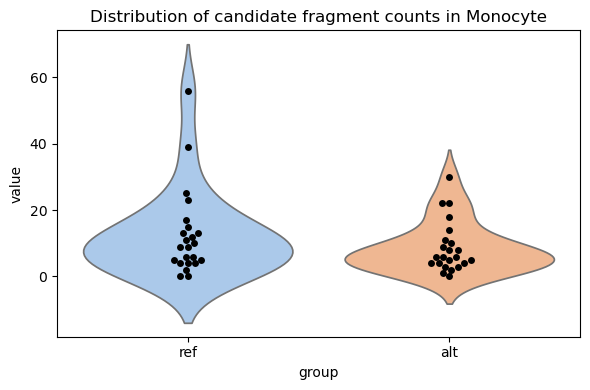

Macrophages mean:167.65217391304347


/tmp/ipykernel_51594/272113710.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="group", y="value", data=df, inner=None, palette="pastel")


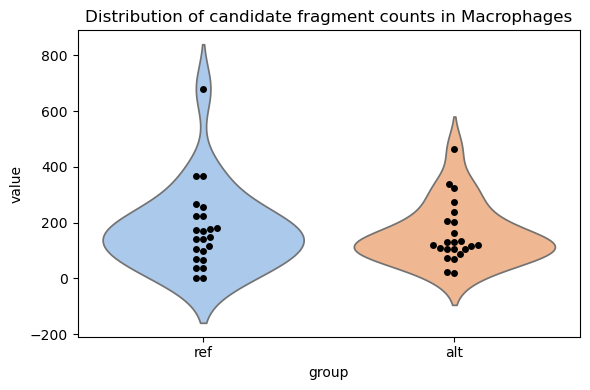

Muscle cell mean:376.6304347826087


/tmp/ipykernel_51594/272113710.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="group", y="value", data=df, inner=None, palette="pastel")


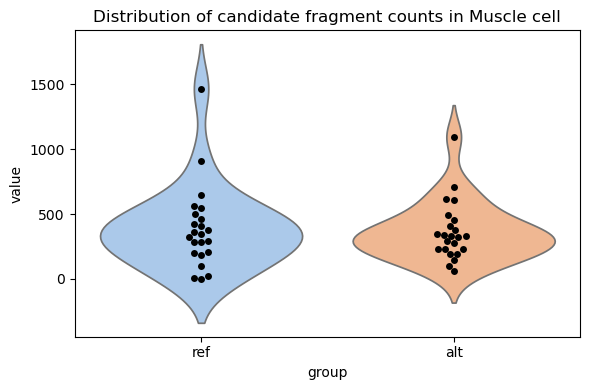

Fibroblast mean:24.0


/tmp/ipykernel_51594/272113710.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="group", y="value", data=df, inner=None, palette="pastel")


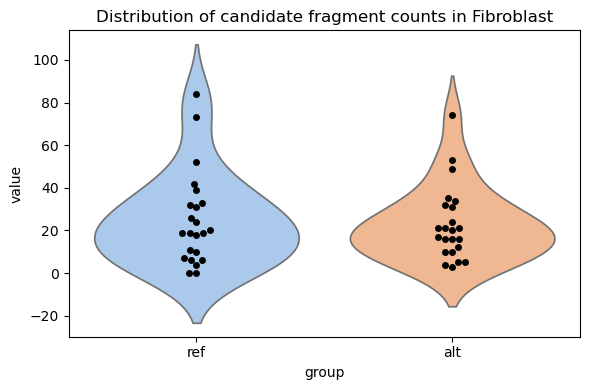

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
for cell_type in set(scRNA_snp['cell_type']):
    sub = scRNA_snp[scRNA_snp['cell_type']==cell_type]
    cell_counts = sub['cell_ref_counts'].tolist()+sub['cell_alt_counts'].tolist()
    # 示例数据
    print(f"{cell_type} mean:{np.mean(cell_counts)}")
    df = pd.DataFrame({
        "value": cell_counts,
        "group": ["ref"]*23 + ["alt"]*23  # 如果有分组
    })

    plt.figure(figsize=(6,4))
    sns.violinplot(x="group", y="value", data=df, inner=None, palette="pastel")
    sns.swarmplot(x="group", y="value", data=df, color="k", size=5)
    plt.title(f"Distribution of candidate fragment counts in {cell_type}")
    plt.tight_layout()
    plt.savefig(f"/data2/chenruipu/data/xulingna/snp/scRNA/scripts/figures/{cell_type}_counts_violin.pdf")
    plt.show()

测试位点是否在GWAS结果里

In [4]:
import pandas as pd
hg19=pd.read_csv('snp_hg19.bed',sep='\t',header=None)
hg19

,0,1,2,3,4
0,chr1,11072117,11072117,chr1:11012061-11012060,1
1,chr1,11072885,11072885,chr1:11012829-11012828,1
2,chr1,11073507,11073507,chr1:11013451-11013450,1
3,chr1,11074250,11074250,chr1:11014194-11014193,1
4,chr1,11074420,11074420,chr1:11014364-11014363,1
...,...,...,...,...,...
6029,chr22,41777913,41777913,chr22:41381910-41381909,1
6030,chr22,41779073,41779073,chr22:41383070-41383069,1
6031,chr22,41779971,41779971,chr22:41383968-41383967,1
6032,chr22,41781094,41781094,chr22:41385091-41385090,1


In [5]:
gwas = pd.read_csv('GWAS_info.tsv',sep='\t',header=0)
gwas

,SNP,CHR,BP,ALLELE1,ALLELE0,A1FREQ,BETA,SE,CHISQ_BOLT_LMM,P_BOLT_LMM
0,rs35167234,1,8393871,T,C,0.278575,-0.041343,0.007569,30.4758,3.400000e-08
1,rs9442598,1,9430873,T,C,0.507066,-0.038757,0.006839,31.5430,2.000000e-08
2,rs2235699,1,10820215,A,G,0.724255,-0.050855,0.007721,43.4593,4.300000e-11
3,rs7512641,1,10822171,A,T,0.740849,-0.050375,0.007802,40.7588,1.700000e-10
4,rs2073017,1,10822808,C,T,0.787253,-0.049603,0.008337,34.4410,4.400000e-09
...,...,...,...,...,...,...,...,...,...,...
20944,rs3788584,22,41779073,A,T,0.223782,-0.045779,0.008172,30.3285,3.600000e-08
20945,rs767593,22,41779971,T,G,0.223755,-0.045832,0.008173,30.3979,3.500000e-08
20946,rs73176685,22,41781094,G,C,0.242472,-0.044476,0.007949,30.3229,3.700000e-08
20947,rs371328828,22,41925767,GT,G,0.210802,-0.049864,0.008539,32.3668,1.300000e-08


In [6]:
merged = pd.merge(hg19,gwas,how='inner',left_on=[1],right_on=['BP'])
merged['hg38'] = merged[3].str.split(':').str[1].str.split('-').str[1]

In [7]:
first_step_5642_gwas = merged[[0,'hg38']]
first_step_5642_gwas['hg38_copy'] = first_step_5642_gwas['hg38']
first_step_5642_gwas.to_csv('first_step_5624_gwas_snp_hg38.bed',sep='\t',index=False,header=False)

/tmp/ipykernel_11987/2299505882.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  first_step_5642_gwas['hg38_copy'] = first_step_5642_gwas['hg38']


In [8]:
len(first_step_5642_gwas['hg38'])

5624

In [9]:
merged.columns

Index([               0,                1,                2,                3,
                      4,            'SNP',            'CHR',             'BP',
              'ALLELE1',        'ALLELE0',         'A1FREQ',           'BETA',
                   'SE', 'CHISQ_BOLT_LMM',     'P_BOLT_LMM',           'hg38'],
      dtype='object')

In [10]:
first_step_5642_gwas_info = merged[['SNP','CHR','BP','hg38','ALLELE1','ALLELE0','A1FREQ','BETA','SE','CHISQ_BOLT_LMM','P_BOLT_LMM']]

In [11]:
encode = pd.read_csv('/data2/chenruipu/data/xulingna/snp/select_file/encode_2025_0911/first_step_5642_gwas_snp_hg38_overlap_encode.bed',sep='\t',header=None)
encode = encode.drop_duplicates(subset=[1],keep='first')
encode_list = encode[1].astype(str).to_list()

In [12]:
len(encode_list)

4235

In [13]:
first_step_5642_gwas_info['encode'] = 'N'

/tmp/ipykernel_11987/3849894771.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  first_step_5642_gwas_info['encode'] = 'N'


In [14]:
first_step_5642_gwas_info['encode'] = first_step_5642_gwas_info.apply(lambda row: 'Y' if str(row['hg38']) in encode_list else 'N', axis=1) 

/tmp/ipykernel_11987/2844519501.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  first_step_5642_gwas_info['encode'] = first_step_5642_gwas_info.apply(lambda row: 'Y' if str(row['hg38']) in encode_list else 'N', axis=1)


In [15]:
first_step_5642_gwas_info

,SNP,CHR,BP,hg38,ALLELE1,ALLELE0,A1FREQ,BETA,SE,CHISQ_BOLT_LMM,P_BOLT_LMM,encode
0,rs9430335,1,11072117,11012060,T,C,0.838210,-0.057258,0.009203,37.6818,8.300000e-10,Y
1,rs4133584,1,11072885,11012828,T,C,0.819431,-0.057744,0.008796,42.2234,8.100000e-11,Y
2,1:11073507_TCA_T,1,11073507,11013450,T,TCA,0.837521,-0.057668,0.009184,38.5376,5.400000e-10,Y
3,rs3765895,1,11074250,11014193,G,A,0.837998,-0.057446,0.009184,38.1356,6.600000e-10,Y
4,rs3765896,1,11074420,11014363,A,G,0.838246,-0.057360,0.009188,37.9389,7.300000e-10,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
5619,rs2234059,22,41777913,41381909,C,T,0.223781,-0.045745,0.008172,30.2951,3.700000e-08,Y
5620,rs3788584,22,41779073,41383069,A,T,0.223782,-0.045779,0.008172,30.3285,3.600000e-08,Y
5621,rs767593,22,41779971,41383967,T,G,0.223755,-0.045832,0.008173,30.3979,3.500000e-08,Y
5622,rs73176685,22,41781094,41385090,G,C,0.242472,-0.044476,0.007949,30.3229,3.700000e-08,Y


In [16]:
eQTL= pd.read_csv('/data2/chenruipu/data/xulingna/snp/loop_result/Muscle_Skeletal.v8.signif_variant_gene_pairs.txt',sep='\t')
eQTL['hg38_pos']=eQTL['variant_id'].str.split('_',expand=True)[0]+':'+eQTL['variant_id'].str.split('_',expand=True)[1]

In [17]:
eQTL_list = eQTL['hg38_pos'].str.split(':',expand=True)[1].to_list()

In [18]:
first_step_5642_gwas_info['eQTL'] = 'N'
first_step_5642_gwas_info['eQTL'] = first_step_5642_gwas_info.apply(lambda row: 'Y' if str(row['hg38']) in eQTL_list else 'N', axis=1)

/tmp/ipykernel_11987/2563160915.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  first_step_5642_gwas_info['eQTL'] = 'N'


KeyboardInterrupt: 

In [38]:
first_step_5642_gwas_info[(first_step_5642_gwas_info['encode'] =='N')&(first_step_5642_gwas_info['eQTL']=='N')]

,SNP,CHR,BP,hg38,ALLELE1,ALLELE0,A1FREQ,BETA,SE,CHISQ_BOLT_LMM,P_BOLT_LMM,encode,eQTL
339,rs7543532,1,56577257,56111585,A,G,0.181872,0.053461,0.008773,39.2262,3.800000e-10,N,N
340,rs6680237,1,56586870,56121198,G,C,0.227321,0.048048,0.008087,37.2532,1.000000e-09,N,N
341,rs946197,1,56602308,56136636,C,G,0.231205,0.046640,0.008038,35.7747,2.200000e-09,N,N
342,rs706399,1,56641502,56175830,A,T,0.222894,0.045361,0.008118,33.4482,7.300000e-09,N,N
343,rs12136702,1,56688259,56222587,A,G,0.172430,0.052464,0.008941,36.3906,1.600000e-09,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5574,rs371622054,21,18102683,16730364,TTTA,T,0.590575,-0.044608,0.007027,39.7523,2.900000e-10,N,N
5575,rs35853746,21,18112217,16739898,T,A,0.321346,0.053701,0.007295,54.0290,2.000000e-13,N,N
5576,rs62221733,21,18119734,16747415,G,A,0.264987,0.049667,0.008080,37.8069,7.800000e-10,N,N
5577,rs4535143,21,18131096,16758777,T,C,0.327414,0.050884,0.007280,48.8502,2.800000e-12,N,N


In [39]:
first_step_5642_gwas_info.to_csv('first_step_5624_gwas_info.csv',sep = ',',index=False)

In [45]:
first_step_5642_gwas_info

,SNP,CHR,BP,hg38,ALLELE1,ALLELE0,A1FREQ,BETA,SE,CHISQ_BOLT_LMM,P_BOLT_LMM,encode,eQTL
0,rs9430335,1,11072117,11012060,T,C,0.838210,-0.057258,0.009203,37.6818,8.300000e-10,Y,Y
1,rs4133584,1,11072885,11012828,T,C,0.819431,-0.057744,0.008796,42.2234,8.100000e-11,Y,Y
2,1:11073507_TCA_T,1,11073507,11013450,T,TCA,0.837521,-0.057668,0.009184,38.5376,5.400000e-10,Y,Y
3,rs3765895,1,11074250,11014193,G,A,0.837998,-0.057446,0.009184,38.1356,6.600000e-10,Y,Y
4,rs3765896,1,11074420,11014363,A,G,0.838246,-0.057360,0.009188,37.9389,7.300000e-10,Y,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5619,rs2234059,22,41777913,41381909,C,T,0.223781,-0.045745,0.008172,30.2951,3.700000e-08,Y,Y
5620,rs3788584,22,41779073,41383069,A,T,0.223782,-0.045779,0.008172,30.3285,3.600000e-08,Y,Y
5621,rs767593,22,41779971,41383967,T,G,0.223755,-0.045832,0.008173,30.3979,3.500000e-08,Y,Y
5622,rs73176685,22,41781094,41385090,G,C,0.242472,-0.044476,0.007949,30.3229,3.700000e-08,Y,Y


In [19]:
all_snp = pd.read_csv('all_snp.bed',sep='\t',header=None)
all_snp[2] =all_snp[2].astype(str)

In [42]:
merged

,0,1,2,3,4,SNP,CHR,BP,ALLELE1,ALLELE0,A1FREQ,BETA,SE,CHISQ_BOLT_LMM,P_BOLT_LMM,hg38
0,chr1,11072117,11072117,chr1:11012061-11012060,1,rs9430335,1,11072117,T,C,0.838210,-0.057258,0.009203,37.6818,8.300000e-10,11012060
1,chr1,11072885,11072885,chr1:11012829-11012828,1,rs4133584,1,11072885,T,C,0.819431,-0.057744,0.008796,42.2234,8.100000e-11,11012828
2,chr1,11073507,11073507,chr1:11013451-11013450,1,1:11073507_TCA_T,1,11073507,T,TCA,0.837521,-0.057668,0.009184,38.5376,5.400000e-10,11013450
3,chr1,11074250,11074250,chr1:11014194-11014193,1,rs3765895,1,11074250,G,A,0.837998,-0.057446,0.009184,38.1356,6.600000e-10,11014193
4,chr1,11074420,11074420,chr1:11014364-11014363,1,rs3765896,1,11074420,A,G,0.838246,-0.057360,0.009188,37.9389,7.300000e-10,11014363
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5619,chr22,41777913,41777913,chr22:41381910-41381909,1,rs2234059,22,41777913,C,T,0.223781,-0.045745,0.008172,30.2951,3.700000e-08,41381909
5620,chr22,41779073,41779073,chr22:41383070-41383069,1,rs3788584,22,41779073,A,T,0.223782,-0.045779,0.008172,30.3285,3.600000e-08,41383069
5621,chr22,41779971,41779971,chr22:41383968-41383967,1,rs767593,22,41779971,T,G,0.223755,-0.045832,0.008173,30.3979,3.500000e-08,41383967
5622,chr22,41781094,41781094,chr22:41385091-41385090,1,rs73176685,22,41781094,G,C,0.242472,-0.044476,0.007949,30.3229,3.700000e-08,41385090


In [20]:
ingwas_snp = pd.merge(merged,all_snp,how='inner',left_on=[0,'hg38'],right_on=[0,2])
snp_ingwas_list = ingwas_snp['3_y'].tolist()


In [21]:
len(snp_ingwas_list)

4164

In [50]:
M18_snp_respectively = pd.read_csv('M18_female_snp_respectively.csv')
M18_snp_respectively = M18_snp_respectively[M18_snp_respectively['Row.names'].isin(snp_ingwas_list)]
M18_snp_respectively = M18_snp_respectively[['Row.names','baseMean.x','log2FoldChange.x','padj.x','baseMean.y','log2FoldChange.y','padj.y','LFC_dif','padj']]
M18_snp_respectively.columns = ['snp_id','ref_baseMean','ref_log2FoldChange','ref_padj','alt_baseMean','alt_log2FoldChange','alt_padj','LFC_dif','fisher_padj']
M18_snp_respectively.to_csv('M18_gwas_snp_respectively.csv',index=False)

In [ ]:
M18_snp_respectively

In [52]:
M18_snp_respectively['hg38'] = M18_snp_respectively['snp_id'].str.split(':',expand=True)[1]

In [53]:
M18_snp_respectively_gwas_info = pd.merge(M18_snp_respectively,first_step_5642_gwas_info,how='left',left_on=['hg38'],right_on=['hg38'])

In [23]:
snp_ingwas_list = [item for item in snp_ingwas_list if "A:A" not in item]
snp_ingwas_list = [item for item in snp_ingwas_list if "T:T" not in item]
snp_ingwas_list = [item for item in snp_ingwas_list if "C:C" not in item]
snp_ingwas_list = [item for item in snp_ingwas_list if "G:G" not in item]

In [24]:
len(snp_ingwas_list)

3958

In [25]:
M18_snp_respectively_gwas_info

NameError: name 'M18_snp_respectively_gwas_info' is not defined

In [57]:
M18_snp_respectively_gwas_info = M18_snp_respectively_gwas_info[M18_snp_respectively_gwas_info['snp_id'].isin(snp_ingwas_list)]
M18_snp_respectively_gwas_info.to_csv('M18_gwas_snp_respectively_gwas_info.csv',index=False)

In [30]:
M18_effective_snp = pd.read_csv('/data2/chenruipu/data/xulingna/snp/M18_effective_snp_eQTL_TF.tsv',sep='\t')

In [31]:
M18_effective_snp = M18_effective_snp[M18_effective_snp['snp_id'].isin(snp_ingwas_list)]

In [32]:
M18_effective_snp.to_csv('/data2/chenruipu/data/xulingna/snp/M18_effective_snp_eQTL_TF_ingwas.tsv',sep='\t')

In [7]:
scRNA_targe = ['109738751',
 '123929551',
 '123936906',
 '123957333',
 '32051969',
 '32255481',
 '34311623',
 '34311624',
 '34513848',
 '34583483',
 '34624251',
 '34704973',
 '34819901',
 '34990448',
 '35274101',
 '35361116',
 '35372647',
 '35388671',
 '35471711',
 '35471850',
 '35473753',
 '45928488',
 '45941152']

In [28]:
starr[2].to_list()

['11012060',
 '11012828',
 '11014193',
 '11014363',
 '11015454',
 '11015768',
 '11018168',
 '11018255',
 '11018340',
 '11019020',
 '11019356',
 '11021823',
 '11026275',
 '11026382',
 '11026660',
 '11027467',
 '11027778',
 '11030859',
 '11031148',
 '11034982',
 '11040841',
 '11045049',
 '11046302',
 '11052779',
 '11059078',
 '11064828',
 '11064855',
 '11064886',
 '11064922',
 '11064993',
 '11065676',
 '11065809',
 '11066342',
 '11066375',
 '11066433',
 '11066460',
 '11066512',
 '11066884',
 '11067454',
 '11067707',
 '11067814',
 '11067944',
 '11068272',
 '11068597',
 '11069202',
 '11069377',
 '11069380',
 '11069791',
 '11070059',
 '11070361',
 '11070586',
 '11071376',
 '11072160',
 '11072484',
 '11072504',
 '11072581',
 '11072744',
 '11072908',
 '11073185',
 '11074100',
 '11077721',
 '11081130',
 '11088702',
 '11106245',
 '11111949',
 '11114010',
 '11121270',
 '11130589',
 '11131865',
 '11137410',
 '11138445',
 '11140293',
 '11145001',
 '11147212',
 '11152401',
 '11154525',
 '11154527',

In [54]:
import pandas as pd 
in_gwas = pd.read_csv('M18_effective_snp_eQTL_TF_ingwas.tsv',sep='\t')
del(in_gwas['Unnamed: 0'])
in_gwas = in_gwas.drop_duplicates(keep='first')
in_gwas = in_gwas[(in_gwas['effect']=='strong')&(in_gwas['inTAD']=='yes')&(in_gwas['LFC_dif']*in_gwas['slope']>0)]